In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd

In [3]:
hrdps = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y????m??d??.nc'))
hrdps

['/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d04.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d05.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d06.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d07.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d08.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d09.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d10.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d11.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d12.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d13.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d14.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d15.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d16.nc',
 '/results/forcing/atmospheric/GEM

In [4]:
print(hrdps[0])
print(hrdps[-1])

/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc
/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2014m11d18.nc


HRDPS data is from January 3, 2007 to November 18, 2014

In [5]:
files = sorted(glob.glob('/results/forcing/CanRCM5/*.nc'))
files

['/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_huss.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_pr.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_psl.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_rlds.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_rsds.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_tas.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_uas.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_vas.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_huss.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_pr.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_psl.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rsds.nc',
 '/results/forcing/CanRCM5/sc_nam2

In [6]:
len(files)

120

In [7]:
ds = xr.open_dataset( '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_202101_202112_3h_tas.nc')

In [8]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 2920, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 23kB 2021-01-01 03:00:00 ... 2022-01-01 00:00:00
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB ...
    lat           (rlat, rlon) float64 922kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 47kB ...
    rotated_pole  |S1 1B ...
    tas           (time, rlat, rlon) float32 1GB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ...
    product:                        output
    Conventions:                    CF-1.4
    contact:                        cccma_info@ec.gc.ca
    references:                     http://www.cccma.ec.gc.ca/models
    history:                        created: 2024-09-09 22:01:54 by rcm2nc
    data_licence:                   1) GRANT OF LICENCE - The Government of C...

In [9]:
ds["time"]

<xarray.DataArray 'time' (time: 2920)> Size: 23kB
array([cftime.DatetimeNoLeap(2021, 1, 1, 3, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 1, 1, 6, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 1, 1, 9, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2021, 12, 31, 18, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 31, 21, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 1, 1, 0, 0, 0, 0, has_year_zero=True)],
      shape=(2920,), dtype=object)
Coordinates:
  * time     (time) object 23kB 2021-01-01 03:00:00 ... 2022-01-01 00:00:00
Attributes:
    long_name:      time
    standard_name:  time
    axis:           T
    bounds:         time_bnds

In [10]:
ds.time.values[0]

cftime.DatetimeNoLeap(2021, 1, 1, 3, 0, 0, 0, has_year_zero=True)

In [11]:
print("Start:", ds.time.values[0].strftime("%Y-%m-%d %H:%M:%S"))
print("End:", ds.time.values[-1].strftime("%Y-%m-%d %H:%M:%S"))

Start: 2021-01-01 03:00:00
End: 2022-01-01 00:00:00


In [12]:
ds = xr.open_dataset('/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_tas.nc',)
ds.time.values[0]

cftime.DatetimeNoLeap(2007, 1, 1, 3, 0, 0, 0, has_year_zero=True)

In [13]:
print("Start:", ds.time.values[0].strftime("%Y-%m-%d %H:%M:%S"))
print("End:", ds.time.values[-1].strftime("%Y-%m-%d %H:%M:%S"))

Start: 2007-01-01 03:00:00
End: 2008-01-01 00:00:00


## Using 2009,2010,2011 for training, 2008 for validation and 2012 for testing

In [14]:
years = [2008, 2009, 2010, 2011, 2012]

output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

In [15]:
for year in years:
    print("Processing HRDPS data for",year)
    hrdps_files = sorted(glob.glob(f"/results/forcing/atmospheric/GEM2.5/gemlam/"f"gemlam_y{year}m??d??.nc"))
    
    combined = []
    
    for file in hrdps_files:
        with xr.open_dataset(file) as ds:
            tair = ds["tair"]
            tair = tair.sortby("time_counter")
            time_index = tair.get_index("time_counter")
            if time_index.has_duplicates:
                unique_mask = ~time_index.duplicated()
                tair = tair.isel(time_counter=unique_mask)
            tair_3h = (tair.resample(time_counter="3h",label="left",closed="left",origin="start_day").mean().load())
            combined.append(tair_3h)
    
    ds_hrdps_year = xr.concat(combined, dim="time_counter")
    ds_hrdps_year = ds_hrdps_year.sortby("time_counter")
    time_index = ds_hrdps_year.get_index("time_counter")
    if time_index.has_duplicates:
        unique_mask = ~time_index.duplicated()
        ds_hrdps_year = ds_hrdps_year.isel(time_counter=unique_mask)
    
    with xr.open_dataset(hrdps_files[0]) as ds0:
        lat_hr = ds0["nav_lat"].load()
        lon_hr = ds0["nav_lon"].load()

    ds_hrdps_year = (ds_hrdps_year.to_dataset(name="tair").assign_coords(nav_lat=lat_hr,nav_lon=lon_hr))
    output_file = f"{output_dir}/HRDPS_{year}_tair_3h_with_latlon.nc"
    ds_hrdps_year.to_netcdf(output_file)
    
    print("Saved:", output_file)
    print(
        "Time range:",
        ds_hrdps_year.time_counter.values[0],
        "to",
        ds_hrdps_year.time_counter.values[-1]
    )

Processing HRDPS data for 2008
Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/HRDPS_2008_tair_3h_with_latlon.nc
Time range: 2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
Processing HRDPS data for 2009
Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/HRDPS_2009_tair_3h_with_latlon.nc
Time range: 2009-01-01T00:00:00.000000000 to 2009-12-31T21:00:00.000000000
Processing HRDPS data for 2010
Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/HRDPS_2010_tair_3h_with_latlon.nc
Time range: 2010-01-01T00:00:00.000000000 to 2010-12-31T21:00:00.000000000
Processing HRDPS data for 2011
Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/HRDPS_2011_tair_3h_with_latlon.nc
Time range: 2011-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
Processing HRDPS data for 2012
Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/HRDPS_2012_tair_3h_with_latlon.nc
Time range: 2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [16]:
hrdps_processed_files = []
for year in years:
    file = f"{output_dir}/HRDPS_{year}_tair_3h_with_latlon.nc"
    hrdps_processed_files.append(file)
ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")
ds_hrdps = ds_hrdps.sortby("time_counter")
print(ds_hrdps)

/tmp/ipykernel_1958572/259932316.py:5: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")


<xarray.Dataset> Size: 12GB
Dimensions:       (time_counter: 14592, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
    nav_lat       (time_counter, y, x) float32 4GB 45.61 45.62 ... 52.37 52.37
    nav_lon       (time_counter, y, x) float32 4GB 232.7 232.7 ... 239.6 239.7
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 4GB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>


In [17]:
print("First timestamp:", ds_hrdps.time_counter.values[0])
print("Last timestamp: ", ds_hrdps.time_counter.values[-1])

First timestamp: 2008-01-01T00:00:00.000000000
Last timestamp:  2012-12-31T21:00:00.000000000


In [18]:
# Training: 2009, 2010, and 2011
ds_hrdps_train = ds_hrdps.sel(time_counter=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_hrdps_val = ds_hrdps.sel(time_counter=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_hrdps_test = ds_hrdps.sel(time_counter=slice("2012-01-01", "2012-12-31"))
print("HRDPS Training:")
print(ds_hrdps_train.time_counter.values[0],"to",ds_hrdps_train.time_counter.values[-1])
print("HRDPS Validation:")
print(ds_hrdps_val.time_counter.values[0],"to",ds_hrdps_val.time_counter.values[-1])
print("HRDPS Testing:")
print(ds_hrdps_test.time_counter.values[0],"to",ds_hrdps_test.time_counter.values[-1])

HRDPS Training:
2009-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
HRDPS Validation:
2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
HRDPS Testing:
2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [19]:
ds_hrdps_train

<xarray.Dataset> Size: 7GB
Dimensions:       (time_counter: 8760, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 70kB 2009-01-01 ... 2011-12-3...
    nav_lat       (time_counter, y, x) float32 2GB 45.61 45.62 ... 52.46 52.46
    nav_lon       (time_counter, y, x) float32 2GB 232.7 232.7 ... 239.7 239.8
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 2GB dask.array<chunksize=(2920, 266, 256), meta=np.ndarray>

In [20]:
ds_hrdps_val

<xarray.Dataset> Size: 2GB
Dimensions:       (time_counter: 2912, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2008-01-01 ... 2008-12-3...
    nav_lat       (time_counter, y, x) float32 793MB 45.61 45.62 ... 52.46 52.46
    nav_lon       (time_counter, y, x) float32 793MB 232.7 232.7 ... 239.7 239.8
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 793MB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>

In [21]:
ds_hrdps_val

<xarray.Dataset> Size: 2GB
Dimensions:       (time_counter: 2912, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2008-01-01 ... 2008-12-3...
    nav_lat       (time_counter, y, x) float32 793MB 45.61 45.62 ... 52.46 52.46
    nav_lon       (time_counter, y, x) float32 793MB 232.7 232.7 ... 239.7 239.8
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 793MB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>

In [22]:
print(ds_hrdps_train.time_counter.values[0])
print(ds_hrdps_train.time_counter.values[1])
print(ds_hrdps_train.time_counter.values[2])
print(ds_hrdps_train.time_counter.values[-2])
print(ds_hrdps_train.time_counter.values[-1])

2009-01-01T00:00:00.000000000
2009-01-01T03:00:00.000000000
2009-01-01T06:00:00.000000000
2011-12-31T18:00:00.000000000
2011-12-31T21:00:00.000000000


(array([3.86000000e+02, 1.58542000e+05, 3.21421000e+06, 1.93352370e+07,
        9.20113310e+07, 2.05966875e+08, 2.32200970e+08, 3.38424380e+07,
        4.47993200e+06, 1.35743000e+05]),
 array([230.38404846, 238.91020203, 247.43634033, 255.9624939 ,
        264.48864746, 273.01480103, 281.54095459, 290.06707764,
        298.5932312 , 307.11938477, 315.64553833]),
 <BarContainer object of 10 artists>)

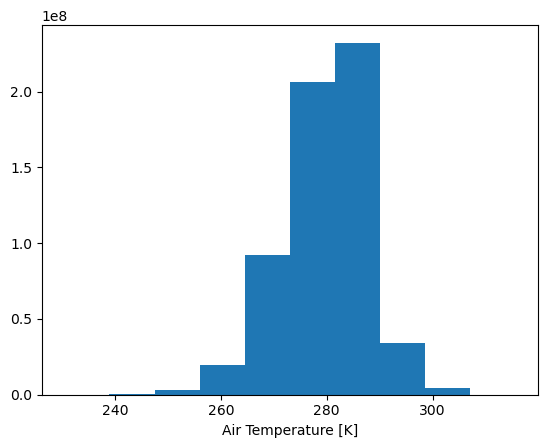

In [23]:
ds_hrdps_train["tair"].plot()

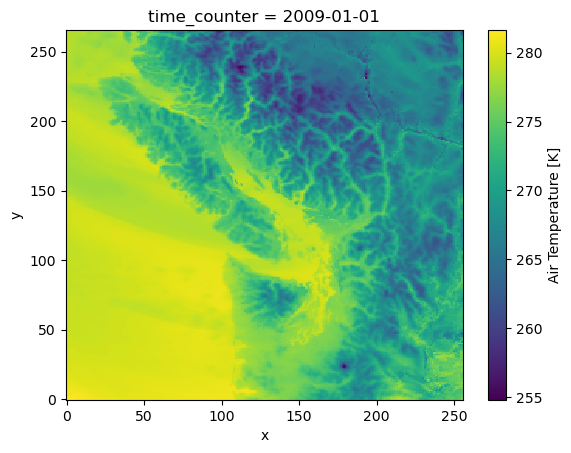

In [24]:
ds_hrdps_train["tair"].isel(time_counter=0).plot()

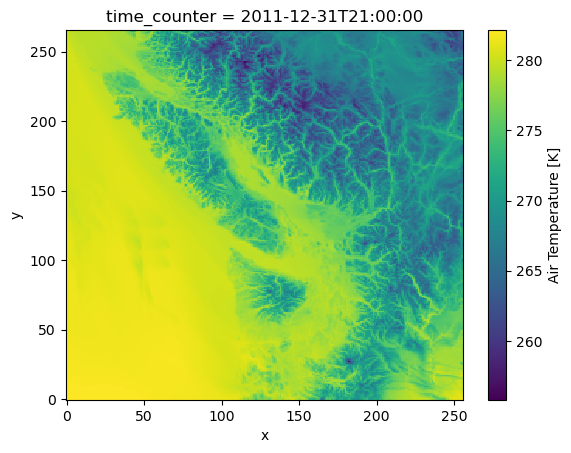

In [25]:
ds_hrdps_train["tair"].sel(time_counter = ds_hrdps_train.time_counter.values[-1]).plot()

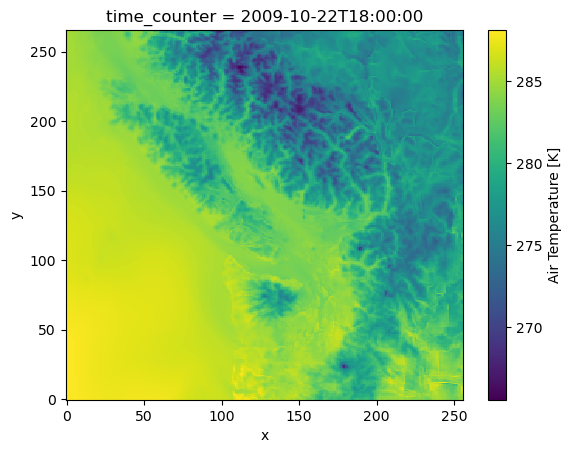

In [26]:
ds_hrdps_train["tair"].sel(time_counter = ds_hrdps_train.time_counter.values[2358]).plot()

In [27]:
canrcm_files = sorted(glob.glob("/results/forcing/CanRCM5/*.nc"))
canrcm_files

['/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_huss.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_pr.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_psl.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_rlds.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_rsds.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_tas.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_uas.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_vas.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_huss.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_pr.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_psl.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc',
 '/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rsds.nc',
 '/results/forcing/CanRCM5/sc_nam2

In [28]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_tas_files = []
for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/"f"*_{year}01_{year}12_3h_tas.nc"))
    canrcm_tas_files.append(matches[0])

print("CanRCM temperature files:")
for file in canrcm_tas_files:
    print(file)

CanRCM temperature files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_tas.nc


In [29]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
ds_canrcm = ds_canrcm.assign_coords(time=ds_canrcm.time.values - timedelta(hours=3))
print(ds_canrcm)

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    tas           (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_1958572/3930337657.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")


In [30]:
print("First timestamp:")
print(ds_canrcm.time.values[0])
print("Last timestamp:")
print(ds_canrcm.time.values[-1])

First timestamp:
2008-01-01 00:00:00
Last timestamp:
2012-12-31 21:00:00


(array([1.88390000e+04, 7.98901000e+05, 8.92563300e+06, 5.52112300e+07,
        1.13520468e+08, 2.22727291e+08, 4.69108407e+08, 6.00585978e+08,
        2.09944372e+08, 1.07888100e+06]),
 array([197.66567993, 210.46574402, 223.26580811, 236.06585693,
        248.86592102, 261.66598511, 274.46606445, 287.26611328,
        300.06616211, 312.86624146, 325.66629028]),
 <BarContainer object of 10 artists>)

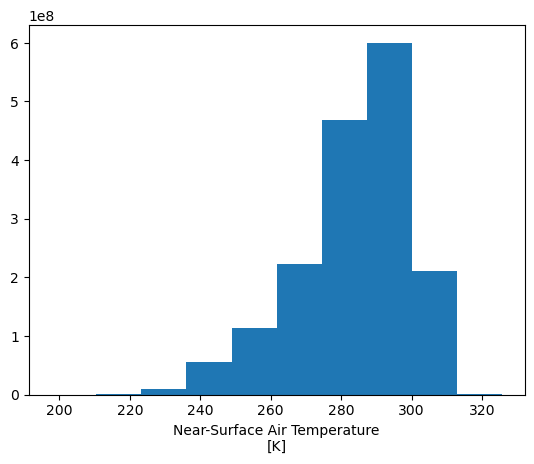

In [31]:
ds_canrcm["tas"].plot()

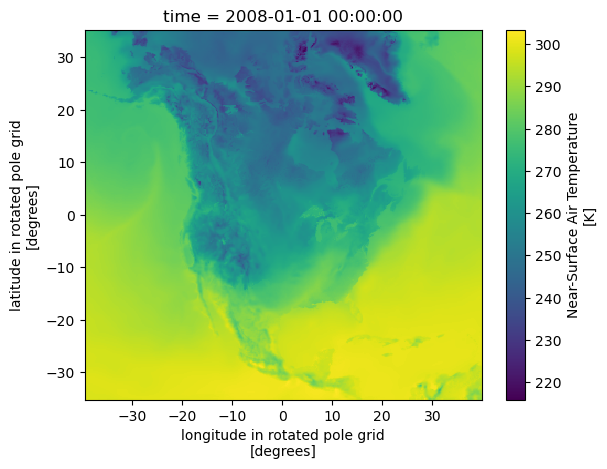

In [32]:
ds_canrcm["tas"].isel(time=0).plot()

In [33]:
lat_hr = ds_hrdps["nav_lat"]
lon_hr = ds_hrdps["nav_lon"]
lon_hr_normalized = ((lon_hr + 180) % 360) - 180
lat_min = float(lat_hr.min())
lat_max = float(lat_hr.max())
lon_min = float(lon_hr_normalized.min())
lon_max = float(lon_hr_normalized.max())
print("HRDPS latitude range:")
print(lat_min, "to", lat_max)
print("HRDPS longitude range:")
print(lon_min, "to", lon_max)

HRDPS latitude range:
45.52116012573242 to 52.4603157043457
HRDPS longitude range:
-129.47222900390625 to -119.20327758789062


In [34]:
lat_lr = ds_canrcm["lat"]
lon_lr = ds_canrcm["lon"]
lon_lr_normalized = ((lon_lr + 180) % 360) - 180
mask_lr = ((lat_lr >= lat_min) &(lat_lr <= lat_max) &(lon_lr_normalized >= lon_min) &(lon_lr_normalized <= lon_max))
i_idx, j_idx = np.where(mask_lr.values)
i_min = i_idx.min()
i_max = i_idx.max()
j_min = j_idx.min()
j_max = j_idx.max()
print("CanRCM grid indices:")
print("rlat:", i_min, "to", i_max)
print("rlon:", j_min, "to", j_max)

CanRCM grid indices:
rlat: 161 to 200
rlon: 79 to 117


In [35]:
ds_canrcm_cut = (ds_canrcm[["tas"]].isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1)))
print(ds_canrcm_cut)

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 14600, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 91MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ..

In [36]:
# Training: 2009, 2010, and 2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31"))
print("CanRCM Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("CanRCM Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("CanRCM Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

CanRCM Training:
2009-01-01 00:00:00 to 2011-12-31 21:00:00
CanRCM Validation:
2008-01-01 00:00:00 to 2008-12-31 21:00:00
CanRCM Testing:
2012-01-01 00:00:00 to 2012-12-31 21:00:00


In [37]:
ds_canrcm_train

<xarray.Dataset> Size: 55MB
Dimensions:  (time: 8760, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 70kB 2009-01-01 00:00:00 ... 2011-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 55MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ...
    product:                        output
    Conventions:                    CF-1.4
    contact:                        cccma_info@ec.gc.ca
    references:                     http://www.cccma.ec.gc.ca/models
    history:                        created: 2024-09-09 21:58:21 by rcm2nc
    data_licence:                   1) GRANT OF LICENCE - The Government of C...

In [38]:
ds_canrcm_val

<xarray.Dataset> Size: 18MB
Dimensions:  (time: 2920, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 23kB 2008-01-01 00:00:00 ... 2008-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 18MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ...
    product:                        output
    Conventions:                    CF-1.4
    contact:                        cccma_info@ec.gc.ca
    references:                     http://www.cccma.ec.gc.ca/models
    history:                        created: 2024-09-09 21:58:21 by rcm2nc
    data_licence:                   1) GRANT OF LICENCE - The Government of C...

In [39]:
ds_canrcm_test

<xarray.Dataset> Size: 18MB
Dimensions:  (time: 2920, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 23kB 2012-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 18MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ...
    product:                        output
    Conventions:                    CF-1.4
    contact:                        cccma_info@ec.gc.ca
    references:                     http://www.cccma.ec.gc.ca/models
    history:                        created: 2024-09-09 21:58:21 by rcm2nc
    data_licence:                   1) GRANT OF LICENCE - The Government of C...

(array([4.370000e+02, 8.687000e+03, 5.999500e+04, 2.353290e+05,
        8.298890e+05, 2.716670e+06, 6.601792e+06, 2.947056e+06,
        2.482630e+05, 1.748200e+04]),
 array([221.95433044, 231.11618042, 240.2780304 , 249.43988037,
        258.60174561, 267.76358032, 276.92544556, 286.08728027,
        295.24914551, 304.41101074, 313.57284546]),
 <BarContainer object of 10 artists>)

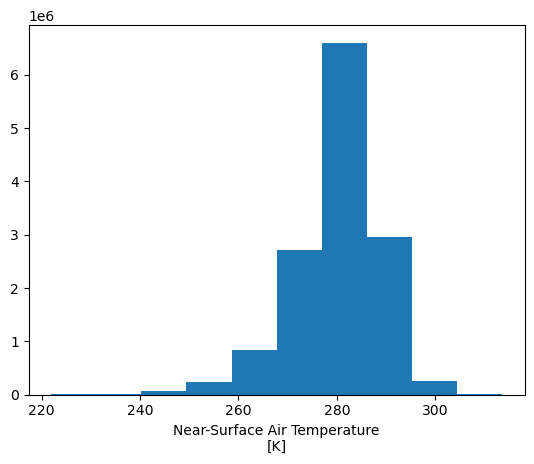

In [40]:
ds_canrcm_train["tas"].plot()

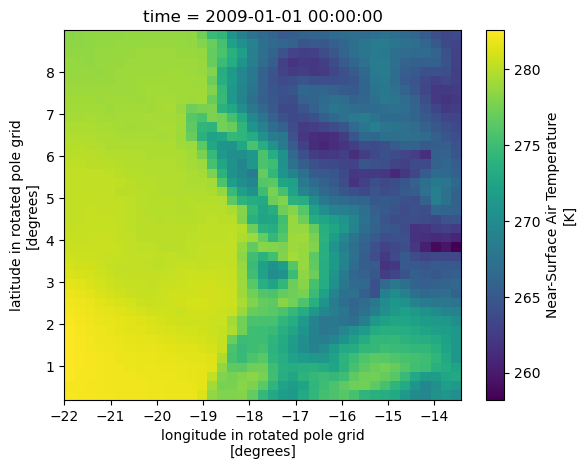

In [41]:
ds_canrcm_train["tas"].isel(time=0).plot()

In [42]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = []
    for t in ds_canrcm_split.time.values:
        canrcm_times.append(time_to_string(t))
    canrcm_times = np.array(canrcm_times)
    
    hrdps_times = []
    for t in ds_hrdps_split.time_counter.values:
        hrdps_times.append(time_to_string(t))
    hrdps_times = np.array(hrdps_times)
    
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    
    return ds_canrcm_aligned, ds_hrdps_aligned

In [43]:
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)
print("Training:")
print("CanRCM:", len(ds_canrcm_train.time))
print("HRDPS: ", len(ds_hrdps_train.time_counter))
print("Validation:")
print("CanRCM:", len(ds_canrcm_val.time))
print("HRDPS: ", len(ds_hrdps_val.time_counter))
print("Testing:")
print("CanRCM:", len(ds_canrcm_test.time))
print("HRDPS: ", len(ds_hrdps_test.time_counter))

Training:
CanRCM: 8760
HRDPS:  8760
Validation:
CanRCM: 2904
HRDPS:  2904
Testing:
CanRCM: 2912
HRDPS:  2912


In [44]:
ds_canrcm_train["tas"]

<xarray.DataArray 'tas' (time: 8760, rlat: 40, rlon: 39)> Size: 55MB
dask.array<getitem, shape=(8760, 40, 39), dtype=float32, chunksize=(2920, 40, 39), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 70kB 2009-01-01 00:00:00 ... 2011-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Attributes:
    long_name:      Near-Surface Air Temperature
    standard_name:  air_temperature
    units:          K
    cell_methods:   time:mean
    grid_mapping:   rotated_pole

In [45]:
X_canrcm_train = ds_canrcm_train["tas"].values.reshape(len(ds_canrcm_train.time),-1).astype(np.float32)
X_hrdps_train = ds_hrdps_train["tair"].values.reshape(len(ds_hrdps_train.time_counter),-1).astype(np.float32)
print("CanRCM training matrix shape:", X_canrcm_train.shape)
print("HRDPS training matrix shape:", X_hrdps_train.shape)
print("Missing CanRCM values:", np.isnan(X_canrcm_train).sum())
print("Missing HRDPS values:", np.isnan(X_hrdps_train).sum())

CanRCM training matrix shape: (8760, 1560)
HRDPS training matrix shape: (8760, 68096)
Missing CanRCM values: 0
Missing HRDPS values: 5175296


In [46]:
X_hrdps_train_raw = (ds_hrdps_train["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_train.time_counter), -1).astype(np.float32))
all_nan_times = np.isnan(X_hrdps_train_raw).all(axis=1)

In [47]:
keep_time = ~all_nan_times
ds_hrdps_train = ds_hrdps_train.isel(time_counter=keep_time)
ds_canrcm_train = ds_canrcm_train.isel(time=keep_time)

In [48]:
X_hrdps_train = (ds_hrdps_train["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_train.time_counter), -1).astype(np.float32))
X_canrcm_train = (ds_canrcm_train["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_train.time), -1).astype(np.float32))

In [49]:
valid_hrdps_cells = np.isfinite(X_hrdps_train).all(axis=0)
X_hrdps_train = X_hrdps_train[:, valid_hrdps_cells]

In [50]:
print("CanRCM matrix shape:", X_canrcm_train.shape)
print("HRDPS matrix shape: ", X_hrdps_train.shape)

CanRCM matrix shape: (8684, 1560)
HRDPS matrix shape:  (8684, 68096)


In [51]:
# Fit PCA
pca_canrcm = PCA()
pca_canrcm.fit(X_canrcm_train)
pca_hrdps = PCA()
pca_hrdps.fit(X_hrdps_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [52]:
pca_canrcm.mean_

array([285.6385 , 285.60947, 285.58395, ..., 272.34198, 271.55798,
       272.00278], shape=(1560,), dtype=float32)

In [53]:
pca_canrcm.components_

array([[ 8.1276242e-03,  8.1979632e-03,  8.2612187e-03, ...,
         3.5837982e-02,  3.5508666e-02,  3.5885140e-02],
       [-1.1469219e-02, -1.1128429e-02, -1.0823995e-02, ...,
        -4.3384887e-02, -4.5926310e-02, -4.6676569e-02],
       [-3.7030771e-02, -3.6211520e-02, -3.5391033e-02, ...,
         2.8793514e-02,  2.9083181e-02,  2.8488113e-02],
       ...,
       [ 1.9730613e-02, -2.2598684e-02,  2.4585498e-02, ...,
         8.2100974e-05, -1.6146549e-04, -3.6433339e-05],
       [-0.0000000e+00, -8.0925273e-03,  6.9681499e-03, ...,
        -1.7202800e-04,  2.4364272e-07, -1.4967551e-05],
       [-0.0000000e+00,  7.5531737e-03, -1.6234770e-02, ...,
         7.7244629e-05, -1.6858539e-04,  6.6525012e-05]],
      shape=(1560, 1560), dtype=float32)

In [54]:
pca_canrcm.explained_variance_ratio_

array([8.7364000e-01, 3.2816220e-02, 2.8925801e-02, ..., 7.0927181e-10,
       7.0373424e-10, 6.9693046e-10], shape=(1560,), dtype=float32)

In [55]:
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
thresholds = [0.90, 0.95, 0.98, 0.99]
print("CanRCM PCs")
for threshold in thresholds:
    n_pcs = np.argmax(canrcm_cumulative_variance >= threshold) + 1
    print(f"{threshold * 100:.0f}% variance explained by " f"{n_pcs} PCs")

print("HRDPS PCs")
for threshold in thresholds:
    n_pcs = np.argmax(hrdps_cumulative_variance >= threshold) + 1
    print(f"{threshold * 100:.0f}% variance explained by "f"{n_pcs} PCs")

CanRCM PCs
90% variance explained by 2 PCs
95% variance explained by 5 PCs
98% variance explained by 20 PCs
99% variance explained by 52 PCs
HRDPS PCs
90% variance explained by 2 PCs
95% variance explained by 6 PCs
98% variance explained by 28 PCs
99% variance explained by 113 PCs


In [56]:
n_canrcm_pcs = np.argmax(canrcm_cumulative_variance >= 0.98) + 1
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1
print("CanRCM PCs to use as predictors:", n_canrcm_pcs)
print("HRDPS PCs to predict:", n_hrdps_pcs)

CanRCM PCs to use as predictors: 20
HRDPS PCs to predict: 28


In [57]:
canrcm_train_scores = pca_canrcm.transform(X_canrcm_train)[:, :n_canrcm_pcs]
hrdps_train_scores = pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_pcs]

In [58]:
canrcm_train_scores.shape

(8684, 20)

In [59]:
hrdps_train_scores.shape

(8684, 28)

In [60]:
regression_model = LinearRegression()
regression_model.fit(canrcm_train_scores,hrdps_train_scores)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
X_canrcm_val = (ds_canrcm_val["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_val.time), -1).astype(np.float32))
X_hrdps_val = (ds_hrdps_val["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_val.time_counter), -1).astype(np.float32))

X_hrdps_val = X_hrdps_val[:, valid_hrdps_cells]
print("CanRCM validation matrix shape:", X_canrcm_val.shape)
print("HRDPS validation matrix shape: ", X_hrdps_val.shape)

CanRCM validation matrix shape: (2904, 1560)
HRDPS validation matrix shape:  (2904, 68096)


In [62]:
valid_val_times = (
    np.isfinite(X_canrcm_val).all(axis=1) &
    np.isfinite(X_hrdps_val).all(axis=1)
)
X_canrcm_val = X_canrcm_val[valid_val_times]
X_hrdps_val = X_hrdps_val[valid_val_times]
print("CanRCM validation matrix shape:", X_canrcm_val.shape)
print("HRDPS validation matrix shape: ", X_hrdps_val.shape)

CanRCM validation matrix shape: (2842, 1560)
HRDPS validation matrix shape:  (2842, 68096)


In [63]:
canrcm_val_scores = (pca_canrcm.transform(X_canrcm_val)[:, :n_canrcm_pcs])
hrdps_val_scores = (pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs])

In [64]:
hrdps_val_scores.shape

(2842, 28)

In [65]:
hrdps_val_scores_pred = regression_model.predict(canrcm_val_scores)

In [66]:
hrdps_val_scores_pred.shape

(2842, 28)

In [67]:
val_r2_average = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="uniform_average")
val_r2_weighted = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="variance_weighted")
val_r2_per_pc = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="raw_values")
print("Validation average R^2:")
print(val_r2_average)
print("Validation variance-weighted R^2:")
print(val_r2_weighted)
print("R^2 for each predicted HRDPS PC:")
print(val_r2_per_pc)

Validation average R^2:
0.2530507743358612
Validation variance-weighted R^2:
0.9503925442695618
R^2 for each predicted HRDPS PC:
[ 0.9831078   0.84039056  0.66552496  0.76766956  0.5105781  -0.21171522
  0.18109012  0.3861751   0.3721047   0.3576737   0.29450208  0.21436912
  0.19081366  0.24306321  0.12260824  0.127433    0.206204    0.09722233
  0.17085218  0.08745468  0.12199908  0.05678737  0.08650857  0.08310831
  0.02133608  0.04904729  0.04926002  0.01025313]


In [68]:
regression_model.coef_.shape

(28, 20)

In [69]:
regression_model.intercept_.shape

(28,)

### Using validation R^2 to find number of PCs

In [70]:
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1
print("Fixed number of HRDPS PCs to predict:", n_hrdps_pcs)
canrcm_train_scores_all = pca_canrcm.transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
hrdps_train_scores = (pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_pcs])
hrdps_val_scores = (pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs])
results = []
max_canrcm_pcs = min(100,canrcm_train_scores_all.shape[1])

for k in range(1, max_canrcm_pcs + 1):
    X_train_k = canrcm_train_scores_all[:, :k]
    X_val_k = canrcm_val_scores_all[:, :k]
    model_k = LinearRegression()
    model_k.fit(X_train_k,hrdps_train_scores)
    Y_val_pred_k = model_k.predict(X_val_k)
    val_r2 = r2_score(hrdps_val_scores,Y_val_pred_k,multioutput="variance_weighted")
    val_rmse = root_mean_squared_error(hrdps_val_scores,Y_val_pred_k)
    results.append({"n_canrcm_pcs": k,"validation_r2": val_r2, "validation_rmse": val_rmse})
results_df = pd.DataFrame(results)
print(results_df)

Fixed number of HRDPS PCs to predict: 28
    n_canrcm_pcs  validation_r2  validation_rmse
0              1       0.884052        88.268326
1              2       0.904119        83.891602
2              3       0.924028        78.216667
3              4       0.931338        75.226608
4              5       0.935458        73.763512
..           ...            ...              ...
95            96       0.955664        61.311062
96            97       0.955634        61.332813
97            98       0.955664        61.331421
98            99       0.955657        61.321407
99           100       0.955678        61.319355

[100 rows x 3 columns]


In [71]:
best_row = results_df.loc[results_df["validation_r2"].idxmax()]
best_n_canrcm_pcs = int(best_row["n_canrcm_pcs"])
best_validation_r2 = float(best_row["validation_r2"])
print("Best number of CanRCM PCs:")
print(best_n_canrcm_pcs)
print("Highest validation R^2:")
print(best_validation_r2)

Best number of CanRCM PCs:
92
Highest validation R^2:
0.9557400941848755


In [72]:
print("Available CanRCM PCs:")
print(pca_canrcm.n_components_)

Available CanRCM PCs:
1560


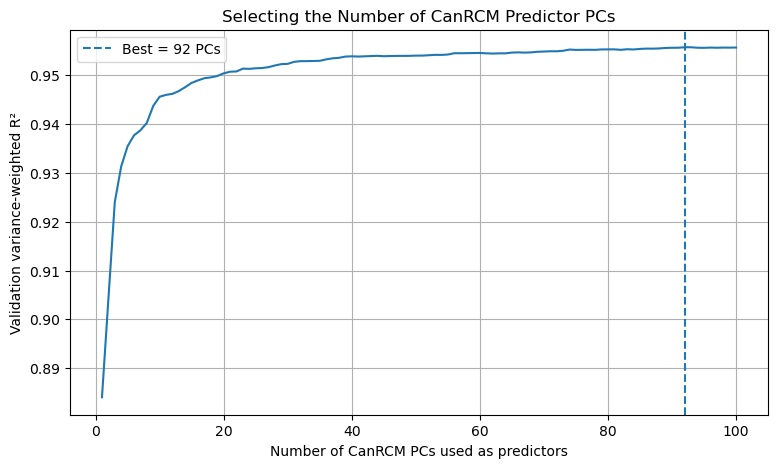

In [73]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_r2"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

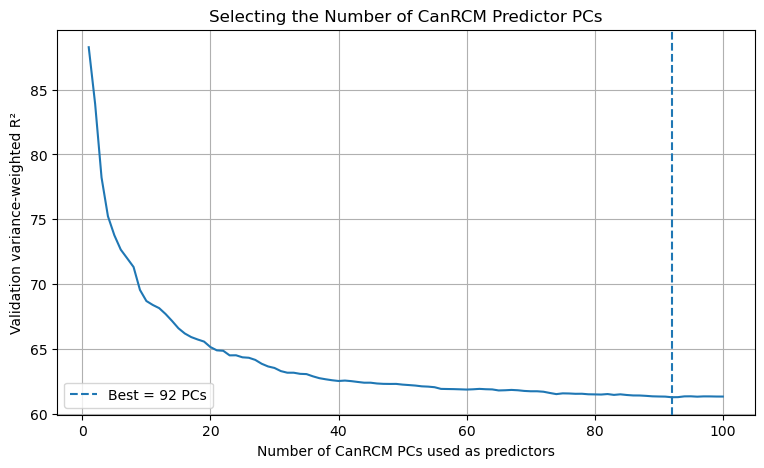

In [74]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_rmse"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1
print("Fixed number of HRDPS PCs to predict:")
print(n_hrdps_pcs)
canrcm_train_scores_all = pca_canrcm.transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
hrdps_train_scores = (pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_pcs])
hrdps_val_scores = (pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs])
results = []
max_canrcm_pcs = min(200,canrcm_train_scores_all.shape[1])

for k in range(1, max_canrcm_pcs + 1):
    X_train_k = canrcm_train_scores_all[:, :k]
    X_val_k = canrcm_val_scores_all[:, :k]
    model_k = LinearRegression()
    model_k.fit(X_train_k,hrdps_train_scores)
    Y_val_pred_k = model_k.predict(X_val_k)
    val_r2 = r2_score(hrdps_val_scores,Y_val_pred_k,multioutput="variance_weighted")
    val_rmse = root_mean_squared_error(hrdps_val_scores,Y_val_pred_k)
    results.append({"n_canrcm_pcs": k,"validation_r2": val_r2, "validation_rmse": val_rmse})
results_df = pd.DataFrame(results)
print(results_df)

Fixed number of HRDPS PCs to predict:
28
     n_canrcm_pcs  validation_r2  validation_rmse
0               1       0.884052        88.268326
1               2       0.904119        83.891602
2               3       0.924028        78.216667
3               4       0.931338        75.226608
4               5       0.935458        73.763512
..            ...            ...              ...
195           196       0.955065        61.673157
196           197       0.954994        61.688515
197           198       0.954942        61.724827
198           199       0.954864        61.749775
199           200       0.954852        61.762112

[200 rows x 3 columns]


In [76]:
best_row = results_df.loc[results_df["validation_r2"].idxmax()]
best_n_canrcm_pcs = int(best_row["n_canrcm_pcs"])
best_validation_r2 = float(best_row["validation_r2"])
print("Best number of CanRCM PCs:")
print(best_n_canrcm_pcs)
print("Highest validation R^2:")
print(best_validation_r2)

Best number of CanRCM PCs:
126
Highest validation R^2:
0.956171989440918


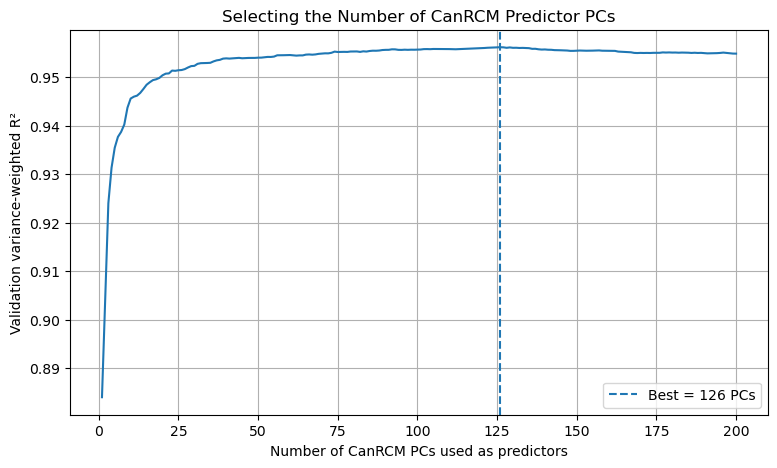

In [77]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_r2"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

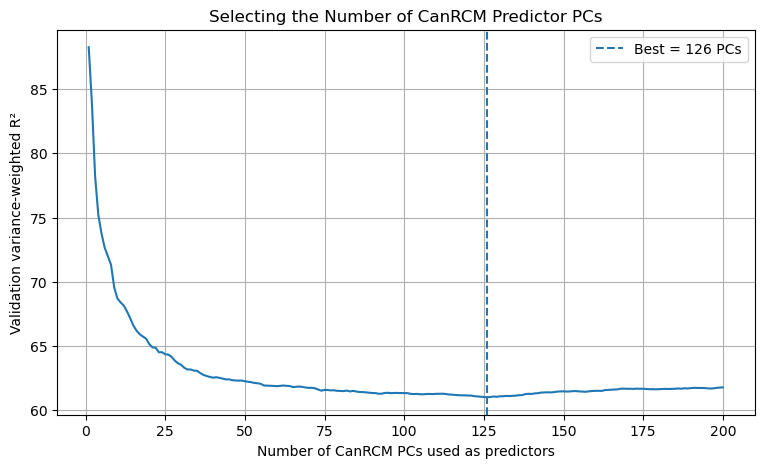

In [78]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_rmse"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1
print("Fixed number of HRDPS PCs to predict:")
print(n_hrdps_pcs)
canrcm_train_scores_all = pca_canrcm.transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
hrdps_train_scores = (pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_pcs])
hrdps_val_scores = (pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs])
results = []
max_canrcm_pcs = min(50,canrcm_train_scores_all.shape[1])

for k in range(1, max_canrcm_pcs + 1):
    X_train_k = canrcm_train_scores_all[:, :k]
    X_val_k = canrcm_val_scores_all[:, :k]
    model_k = LinearRegression()
    model_k.fit(X_train_k,hrdps_train_scores)
    Y_val_pred_k = model_k.predict(X_val_k)
    val_r2 = r2_score(hrdps_val_scores,Y_val_pred_k,multioutput="variance_weighted")
    val_rmse = root_mean_squared_error(hrdps_val_scores,Y_val_pred_k)
    results.append({"n_canrcm_pcs": k,"validation_r2": val_r2, "validation_rmse": val_rmse})
results_df = pd.DataFrame(results)
print(results_df)

Fixed number of HRDPS PCs to predict:
28
    n_canrcm_pcs  validation_r2  validation_rmse
0              1       0.884052        88.268326
1              2       0.904119        83.891602
2              3       0.924028        78.216667
3              4       0.931338        75.226608
4              5       0.935458        73.763512
5              6       0.937691        72.653191
6              7       0.938720        71.987137
7              8       0.940236        71.314148
8              9       0.943715        69.544754
9             10       0.945595        68.690880
10            11       0.945981        68.385689
11            12       0.946193        68.139793
12            13       0.946757        67.686897
13            14       0.947569        67.157616
14            15       0.948437        66.589272
15            16       0.948955        66.185089
16            17       0.949398        65.907822
17            18       0.949563        65.723396
18            19       0.949

In [80]:
best_row = results_df.loc[results_df["validation_r2"].idxmax()]
best_n_canrcm_pcs = int(best_row["n_canrcm_pcs"])
best_validation_r2 = float(best_row["validation_r2"])
print("Best number of CanRCM PCs:")
print(best_n_canrcm_pcs)
print("Highest validation R^2:")
print(best_validation_r2)

Best number of CanRCM PCs:
50
Highest validation R^2:
0.9540195465087891


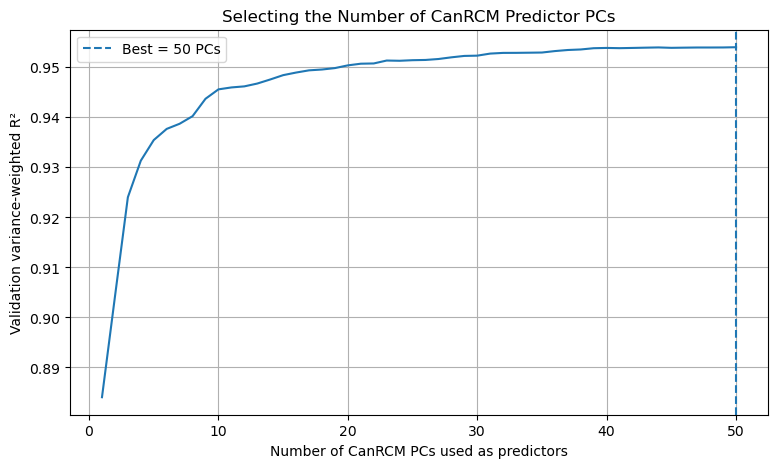

In [81]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_r2"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

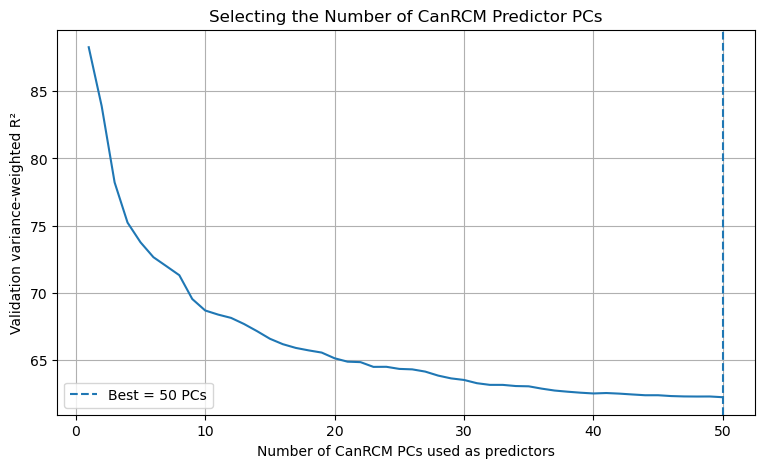

In [82]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_rmse"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1
print("Fixed number of HRDPS PCs to predict:")
print(n_hrdps_pcs)
canrcm_train_scores_all = pca_canrcm.transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
hrdps_train_scores = (pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_pcs])
hrdps_val_scores = (pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs])
results = []
max_canrcm_pcs = min(30,canrcm_train_scores_all.shape[1])

for k in range(1, max_canrcm_pcs + 1):
    X_train_k = canrcm_train_scores_all[:, :k]
    X_val_k = canrcm_val_scores_all[:, :k]
    model_k = LinearRegression()
    model_k.fit(X_train_k,hrdps_train_scores)
    Y_val_pred_k = model_k.predict(X_val_k)
    val_r2 = r2_score(hrdps_val_scores,Y_val_pred_k,multioutput="variance_weighted")
    val_rmse = root_mean_squared_error(hrdps_val_scores,Y_val_pred_k)
    results.append({"n_canrcm_pcs": k,"validation_r2": val_r2, "validation_rmse": val_rmse})
results_df = pd.DataFrame(results)
print(results_df)

Fixed number of HRDPS PCs to predict:
28
    n_canrcm_pcs  validation_r2  validation_rmse
0              1       0.884052        88.268326
1              2       0.904119        83.891602
2              3       0.924028        78.216667
3              4       0.931338        75.226608
4              5       0.935458        73.763512
5              6       0.937691        72.653191
6              7       0.938720        71.987137
7              8       0.940236        71.314148
8              9       0.943715        69.544754
9             10       0.945595        68.690880
10            11       0.945981        68.385689
11            12       0.946193        68.139793
12            13       0.946757        67.686897
13            14       0.947569        67.157616
14            15       0.948437        66.589272
15            16       0.948955        66.185089
16            17       0.949398        65.907822
17            18       0.949563        65.723396
18            19       0.949

In [84]:
best_row = results_df.loc[results_df["validation_r2"].idxmax()]
best_n_canrcm_pcs = int(best_row["n_canrcm_pcs"])
best_validation_r2 = float(best_row["validation_r2"])
print("Best number of CanRCM PCs:")
print(best_n_canrcm_pcs)
print("Highest validation R^2:")
print(best_validation_r2)

Best number of CanRCM PCs:
30
Highest validation R^2:
0.9523341655731201


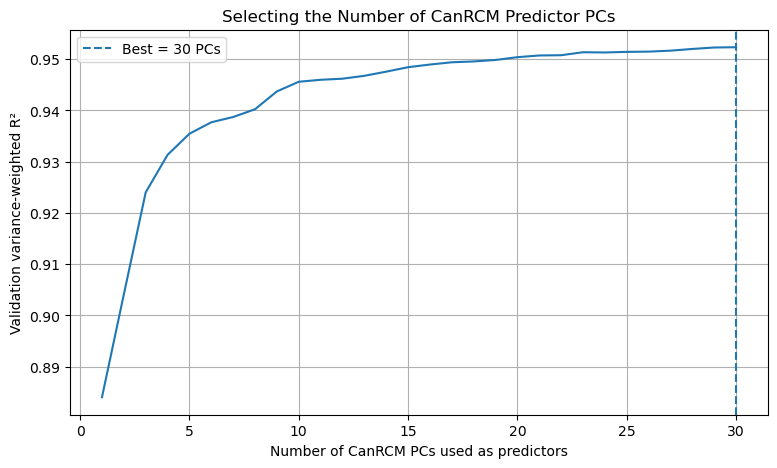

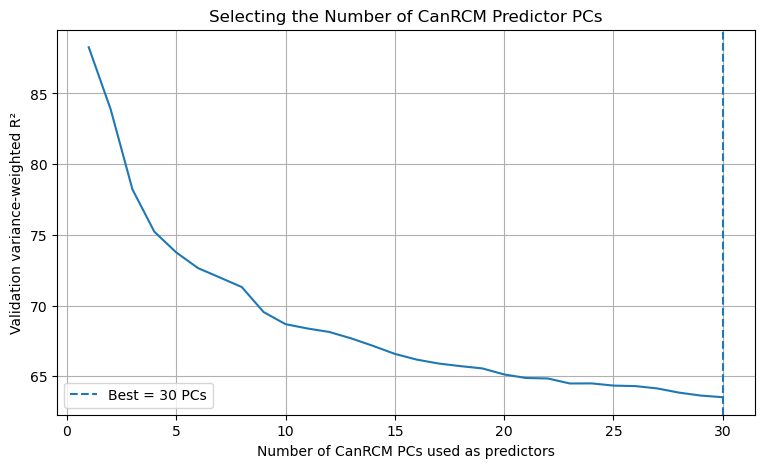

In [85]:
plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_r2"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(results_df["n_canrcm_pcs"],results_df["validation_rmse"])
plt.axvline(best_n_canrcm_pcs,linestyle="--",label=f"Best = {best_n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs used as predictors")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting the Number of CanRCM Predictor PCs")
plt.legend()
plt.grid(True)
plt.show()

For number of canrcm pcs:
- max 30: I get 30 with 0.9523341655731201
- max 50: I get 50 best with max R^2 to be 0.9540195465087891 
- max 100: I get 92 with 0.9557400941848755 
- max 200: I get 126 with 0.956171989440918

Since there is not a lot of difference in the R^2, to keep the model simpler, I will choose 30 pcs.

In [86]:
n_hrdps_final = 28
n_canrcm_final = 30

In [87]:
canrcm_train_scores = (pca_canrcm.transform(X_canrcm_train)[:, :n_canrcm_final])
hrdps_train_scores = (pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_final])
regression_model = LinearRegression()
regression_model.fit(canrcm_train_scores,hrdps_train_scores)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
def reconstruct_hrdps(X_canrcm):
    canrcm_scores = (pca_canrcm.transform(X_canrcm)[:, :n_canrcm_final])
    hrdps_scores_pred = regression_model.predict(canrcm_scores)
    hrdps_scores_pred_full = np.zeros((hrdps_scores_pred.shape[0],pca_hrdps.components_.shape[0]),dtype=np.float32)
    hrdps_scores_pred_full[:, :n_hrdps_final] = hrdps_scores_pred
    X_hrdps_pred = pca_hrdps.inverse_transform(hrdps_scores_pred_full)
    return X_hrdps_pred

In [89]:
X_canrcm_test = (ds_canrcm_test["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_test.time), -1).astype(np.float32))
X_hrdps_test = (ds_hrdps_test["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_test.time_counter), -1).astype(np.float32))

X_hrdps_test = X_hrdps_test[:, valid_hrdps_cells]
print("CanRCM test matrix shape:", X_canrcm_test.shape)
print("HRDPS test matrix shape: ", X_hrdps_test.shape)

valid_test_times = (
    np.isfinite(X_canrcm_test).all(axis=1) &
    np.isfinite(X_hrdps_test).all(axis=1)
)
X_canrcm_test = X_canrcm_test[valid_test_times]
X_hrdps_test = X_hrdps_test[valid_test_times]
print("CanRCM test matrix shape:", X_canrcm_test.shape)
print("HRDPS test matrix shape: ", X_hrdps_test.shape)

CanRCM test matrix shape: (2912, 1560)
HRDPS test matrix shape:  (2912, 68096)
CanRCM test matrix shape: (2912, 1560)
HRDPS test matrix shape:  (2912, 68096)


In [90]:
hrdps_test_scores_actual = (pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_final])
hrdps_test_scores_pred = regression_model.predict(pca_canrcm.transform(X_canrcm_test)[:, :n_canrcm_final])
test_r2_weighted = r2_score(
    hrdps_test_scores_actual,
    hrdps_test_scores_pred,
    multioutput="variance_weighted"
)

print("Test variance-weighted R^2:")
print(test_r2_weighted)

Test variance-weighted R^2:
0.8790320158004761


In [91]:
X_hrdps_val_pred = reconstruct_hrdps(X_canrcm_val)
X_hrdps_test_pred = reconstruct_hrdps(X_canrcm_test)
print("Actual validation shape:", X_hrdps_val.shape)
print("Predicted validation shape:", X_hrdps_val_pred.shape)
print("Actual test shape:", X_hrdps_test.shape)
print("Predicted test shape:", X_hrdps_test_pred.shape)

Actual validation shape: (2842, 68096)
Predicted validation shape: (2842, 68096)
Actual test shape: (2912, 68096)
Predicted test shape: (2912, 68096)


In [92]:
X_hrdps_train_pred = reconstruct_hrdps(X_canrcm_train)

In [93]:
train_times = pd.to_datetime([time_to_string(t) for t in ds_hrdps_train.time_counter.values])
test_times = pd.to_datetime([time_to_string(t)for t in ds_hrdps_test.time_counter.values[valid_test_times]])
val_times = pd.to_datetime([time_to_string(t)for t in ds_hrdps_val.time_counter.values[valid_val_times]])

In [94]:
print("Training:", len(train_times), X_hrdps_train.shape[0])
print("Validation:", len(val_times), X_hrdps_val.shape[0])
print("Testing:", len(test_times), X_hrdps_test.shape[0])

Training: 8684 8684
Validation: 2842 2842
Testing: 2912 2912


In [95]:
def make_mean_timeseries(times, X_actual, X_pred):
    return pd.DataFrame({"actual": X_actual.mean(axis=1),"predicted": X_pred.mean(axis=1)},index=times).sort_index()

In [96]:
train_timeseries = make_mean_timeseries(train_times,X_hrdps_train,X_hrdps_train_pred)
val_timeseries = make_mean_timeseries(val_times,X_hrdps_val,X_hrdps_val_pred)
test_timeseries = make_mean_timeseries(test_times,X_hrdps_test,X_hrdps_test_pred)

<Axes: title={'center': 'Mean HRDPS Temperature for training data'}, ylabel='Temperature (K)'>

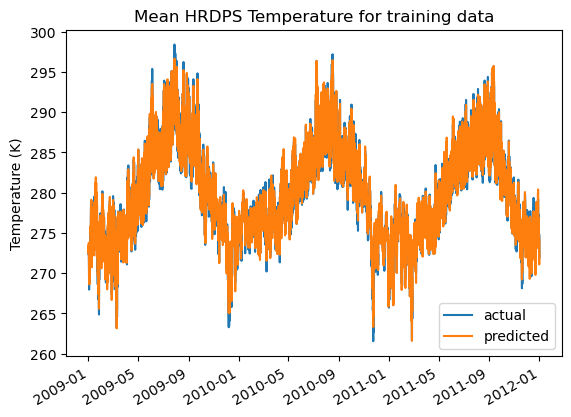

In [97]:
train_timeseries.plot(title="Mean HRDPS Temperature for training data",ylabel="Temperature (K)")

In [98]:
train_timeseries

,actual,predicted
2009-01-01 00:00:00,273.287109,273.404877
2009-01-01 03:00:00,272.667206,272.895691
2009-01-01 06:00:00,272.640594,272.554871
2009-01-01 09:00:00,273.173065,272.416809
2009-01-01 12:00:00,272.557861,272.469330
...,...,...
2011-12-31 09:00:00,272.671661,272.297302
2011-12-31 12:00:00,272.070984,271.274445
2011-12-31 15:00:00,271.859406,271.090057
2011-12-31 18:00:00,273.748444,273.207733


In [99]:
def plot_year(timeseries, year, dataset_name, daily_average=True):
    subset = timeseries.loc[f"{year}-01-01":f"{year}-12-31 23:59:59"].copy()
    if daily_average:
        subset = subset.resample("1D").mean()
        frequency = "Daily average"
    else:
        frequency = "3-hourly values"
    finite_rows = (
    np.isfinite(subset["actual"])
    &
    np.isfinite(subset["predicted"])
    )

    print("Removed rows containing NaN or infinity:", (~finite_rows).sum())

    subset = subset.loc[finite_rows]
    r2 = r2_score(subset["actual"],subset["predicted"])
    rmse = np.sqrt(mean_squared_error(subset["actual"],subset["predicted"]))
    plt.figure(figsize=(14, 5))
    plt.plot(subset.index,subset["actual"],label="Actual HRDPS")
    plt.plot(subset.index,subset["predicted"],label="Predicted HRDPS")
    plt.xlabel("Time")
    plt.ylabel("Spatial-mean air temperature (K)")
    plt.title(
        f"{dataset_name}: Actual vs Predicted HRDPS Temperature: {year}\n"
        f"{frequency} | R² = {r2:.3f}, RMSE = {rmse:.3f} "
    )
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

The function evaluates the model based on the average temperature across the HRDPS grid at each timestamp. It does not measure prediction accuracy separately for each individual grid cell.

Removed rows containing NaN or infinity: 1


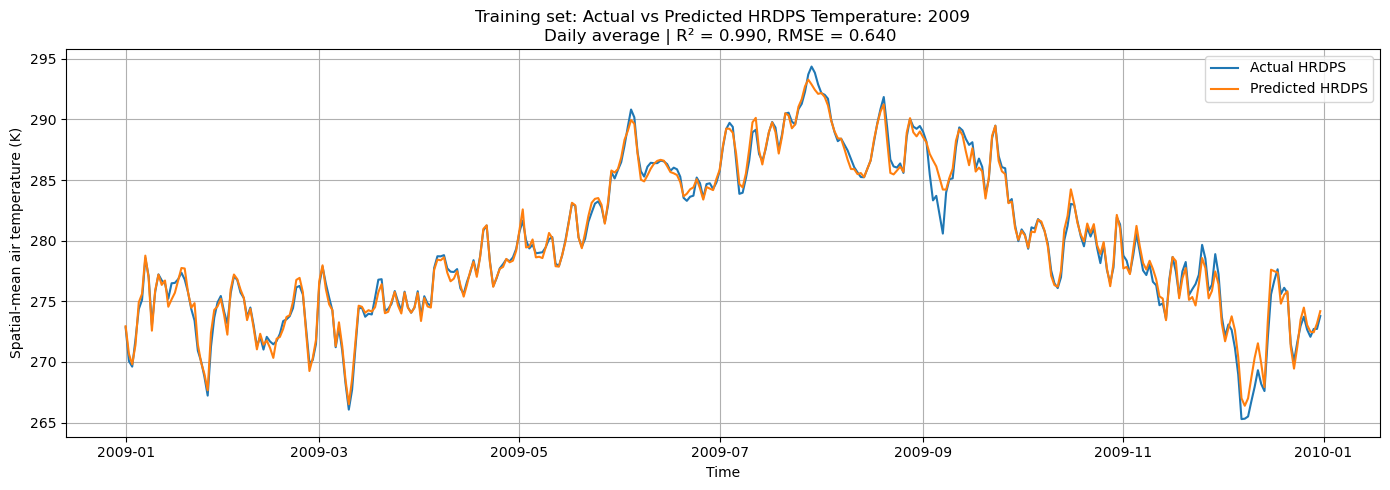

Removed rows containing NaN or infinity: 1


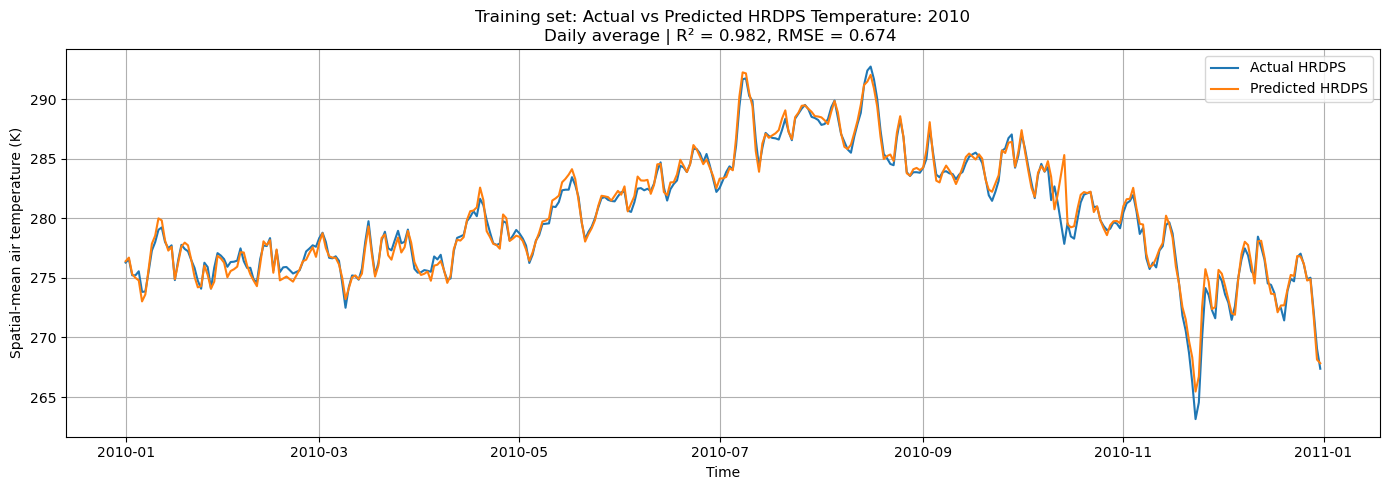

Removed rows containing NaN or infinity: 0


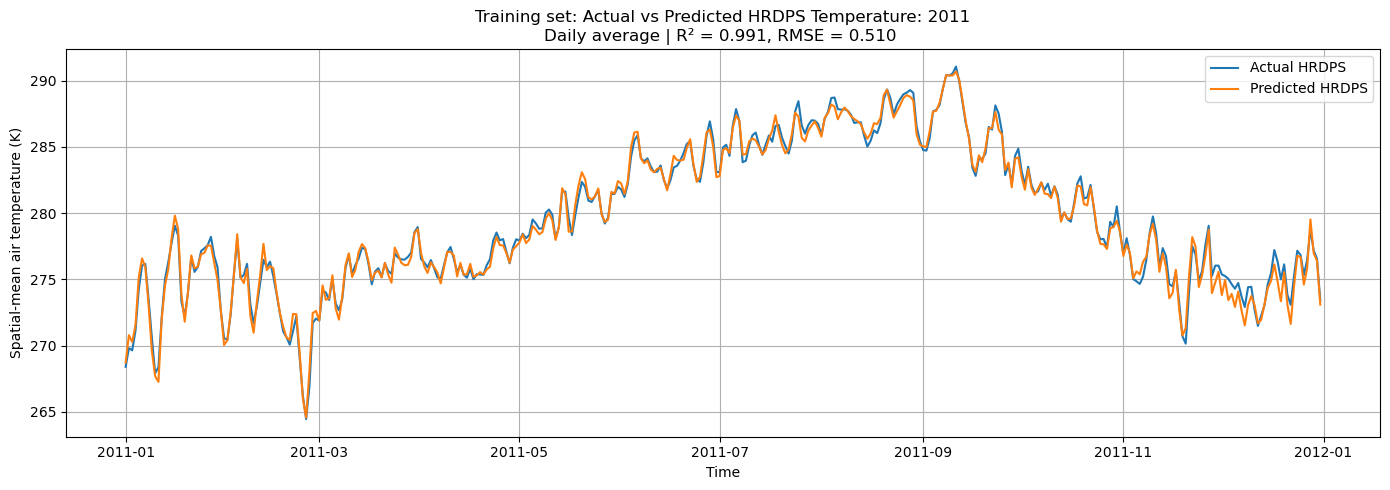

Removed rows containing NaN or infinity: 9


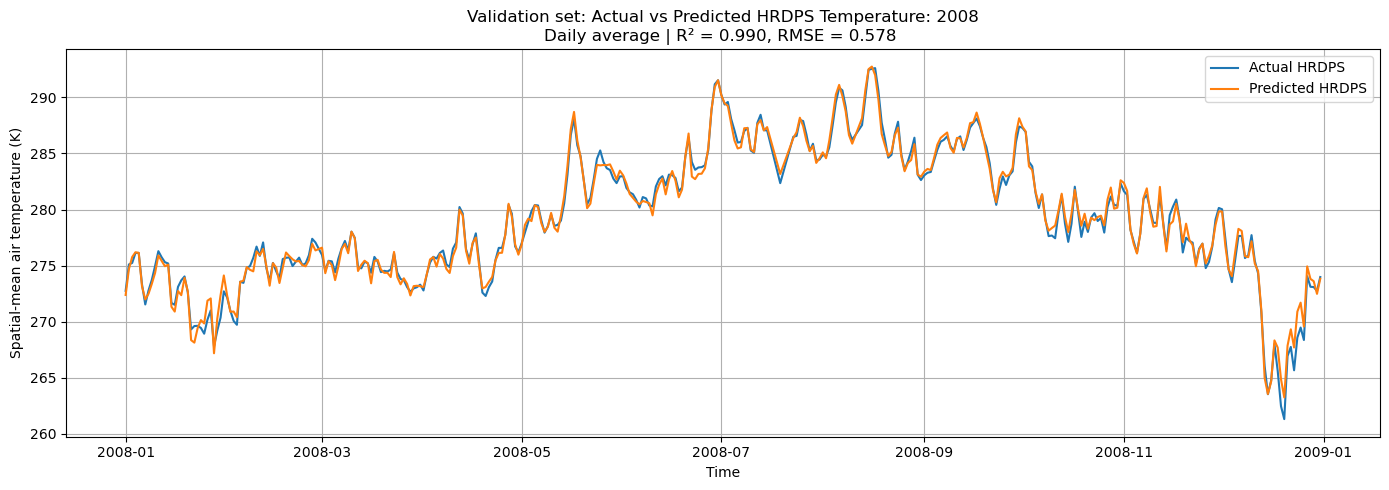

Removed rows containing NaN or infinity: 2


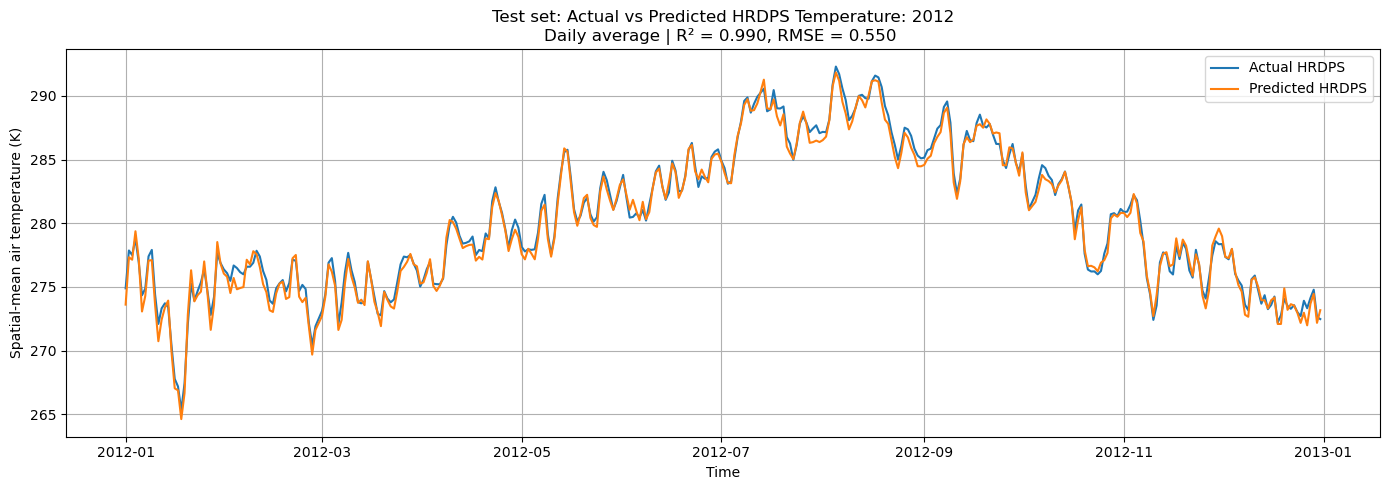

In [100]:
plot_year(train_timeseries, 2009, "Training set")
plot_year(train_timeseries, 2010, "Training set")
plot_year(train_timeseries, 2011, "Training set")
plot_year(val_timeseries, 2008, "Validation set")
plot_year(test_timeseries, 2012, "Test set")

Removed rows containing NaN or infinity: 0


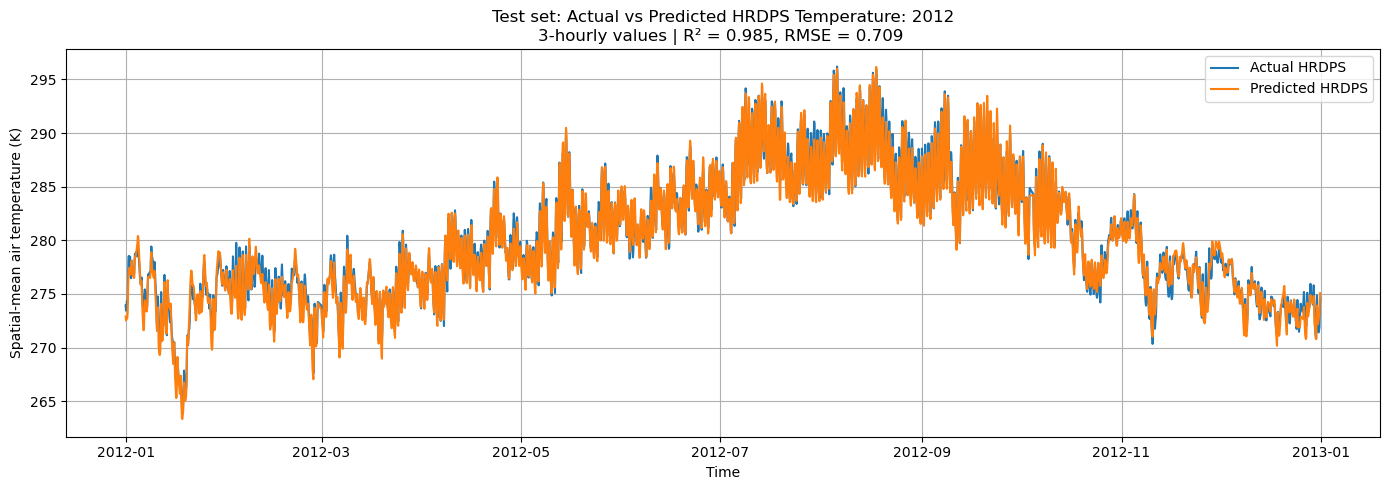

In [101]:
plot_year(test_timeseries, 2012, "Test set", daily_average=False)

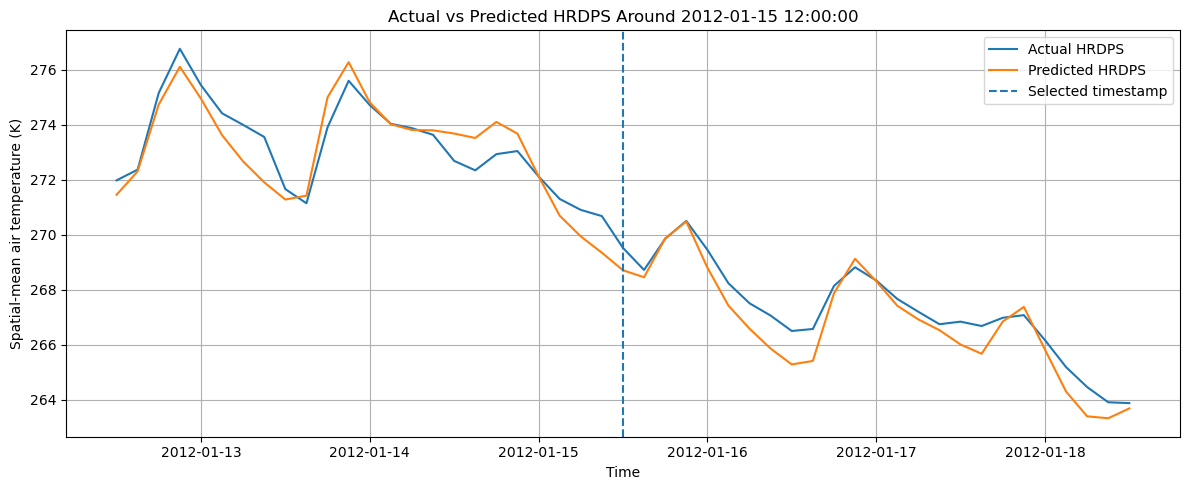

In [102]:
timestamp = pd.Timestamp("2012-01-15 12:00:00")
subset = test_timeseries.loc[timestamp - pd.Timedelta(days=3):timestamp + pd.Timedelta(days=3)]
plt.figure(figsize=(12, 5))
plt.plot(subset.index,subset["actual"],label="Actual HRDPS")
plt.plot(subset.index,subset["predicted"],label="Predicted HRDPS")
plt.axvline(timestamp,linestyle="--",label="Selected timestamp")
plt.xlabel("Time")
plt.ylabel("Spatial-mean air temperature (K)")
plt.title(f"Actual vs Predicted HRDPS Around {timestamp}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

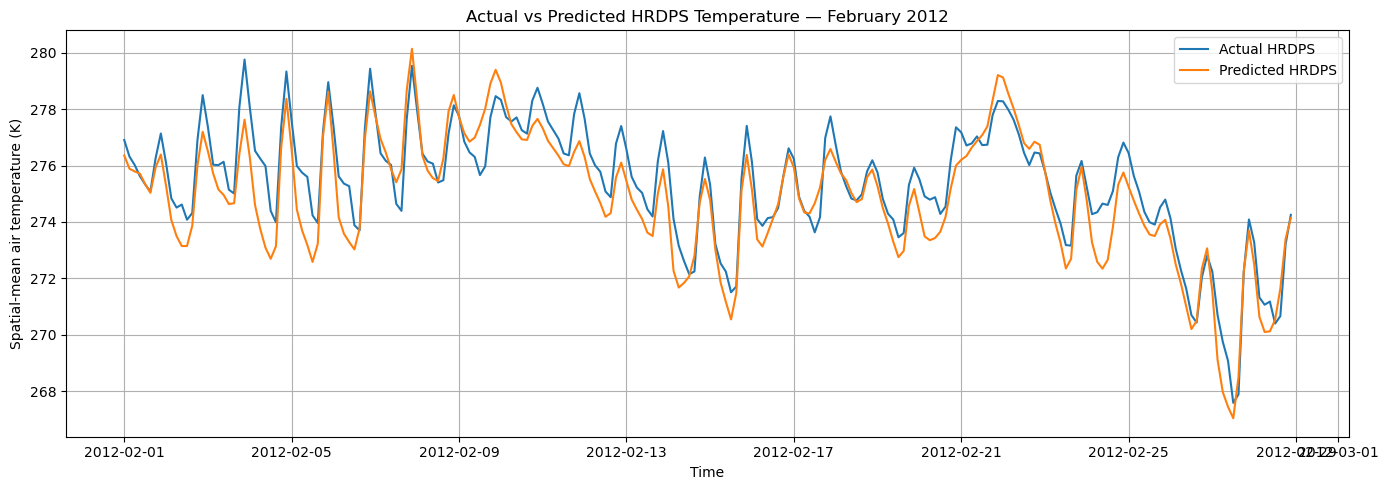

In [103]:
feb_2012 = test_timeseries.loc["2012-02-01":"2012-02-29 23:59:59"]
plt.figure(figsize=(14, 5))
plt.plot(feb_2012.index,feb_2012["actual"],label="Actual HRDPS")
plt.plot(feb_2012.index,feb_2012["predicted"],label="Predicted HRDPS")
plt.xlabel("Time")
plt.ylabel("Spatial-mean air temperature (K)")
plt.title("Actual vs Predicted HRDPS Temperature — February 2012")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
# These are 3 hourly values

In [104]:
def plot_hrdps_6_maps(timestamp,ds_hrdps,X_hrdps,X_hrdps_pred,pca_hrdps,n_hrdps_final,valid_hrdps_cells,filtered_times):
    timestamp = pd.Timestamp(timestamp)
    filtered_times = pd.to_datetime(filtered_times)
    idx = np.where(filtered_times == timestamp)[0]
    if len(idx) == 0:
        raise ValueError("Timestamp not found in filtered_times.")
    idx = idx[0]

    raw_idx = np.where(pd.to_datetime(ds_hrdps.time_counter.values) == timestamp)[0]
    if len(raw_idx) == 0:
        raise ValueError("Timestamp not found in ds_hrdps.time_counter.")
    raw_idx = raw_idx[0]
    A = ds_hrdps["tair"].isel(time_counter=raw_idx).values.squeeze()

    ny, nx = A.shape

    actual_scores = pca_hrdps.transform(X_hrdps[idx:idx+1])[:, :n_hrdps_final]

    actual_scores_full = np.zeros(
        (1, pca_hrdps.components_.shape[0]),
        dtype=np.float32
    )
    actual_scores_full[:, :n_hrdps_final] = actual_scores

    B_valid = pca_hrdps.inverse_transform(actual_scores_full)[0]

    B = np.full(ny * nx, np.nan, dtype=np.float32)
    B[valid_hrdps_cells] = B_valid
    B = B.reshape(ny, nx)

    C_valid = X_hrdps_pred[idx]

    C = np.full(ny * nx, np.nan, dtype=np.float32)
    C[valid_hrdps_cells] = C_valid
    C = C.reshape(ny, nx)

    BA = B - A
    CB = C - B
    CA = C - A

    common_min = np.nanmin([A, B, C])
    common_max = np.nanmax([A, B, C])

    diff_abs_max = np.nanmax(np.abs([BA, CB, CA]))


    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    im0 = axes[0, 0].imshow(A, origin="lower", vmin=common_min, vmax=common_max)
    axes[0, 0].set_title("A: Actual raw HRDPS")
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

    im1 = axes[0, 1].imshow(B, origin="lower", vmin=common_min, vmax=common_max)
    axes[0, 1].set_title(f"B: HRDPS reconstructed from first {n_hrdps_final} actual PCs")
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    im2 = axes[0, 2].imshow(C, origin="lower", vmin=common_min, vmax=common_max)
    axes[0, 2].set_title("C: Predicted HRDPS")
    plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

    im3 = axes[1, 0].imshow(BA, origin="lower", cmap="coolwarm",vmin=-diff_abs_max, vmax=diff_abs_max)
    axes[1, 0].set_title("B - A: PCA reconstruction error")
    plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

    im4 = axes[1, 1].imshow(CB, origin="lower", cmap="coolwarm",vmin=-diff_abs_max, vmax=diff_abs_max)
    axes[1, 1].set_title("C - B: Regression prediction error")
    plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

    im5 = axes[1, 2].imshow(CA, origin="lower", cmap="coolwarm",vmin=-diff_abs_max, vmax=diff_abs_max)
    axes[1, 2].set_title("C - A: Total error")
    plt.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

    for ax in axes.ravel():
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(f"HRDPS comparison at {timestamp}", fontsize=14)
    plt.tight_layout()
    plt.show()

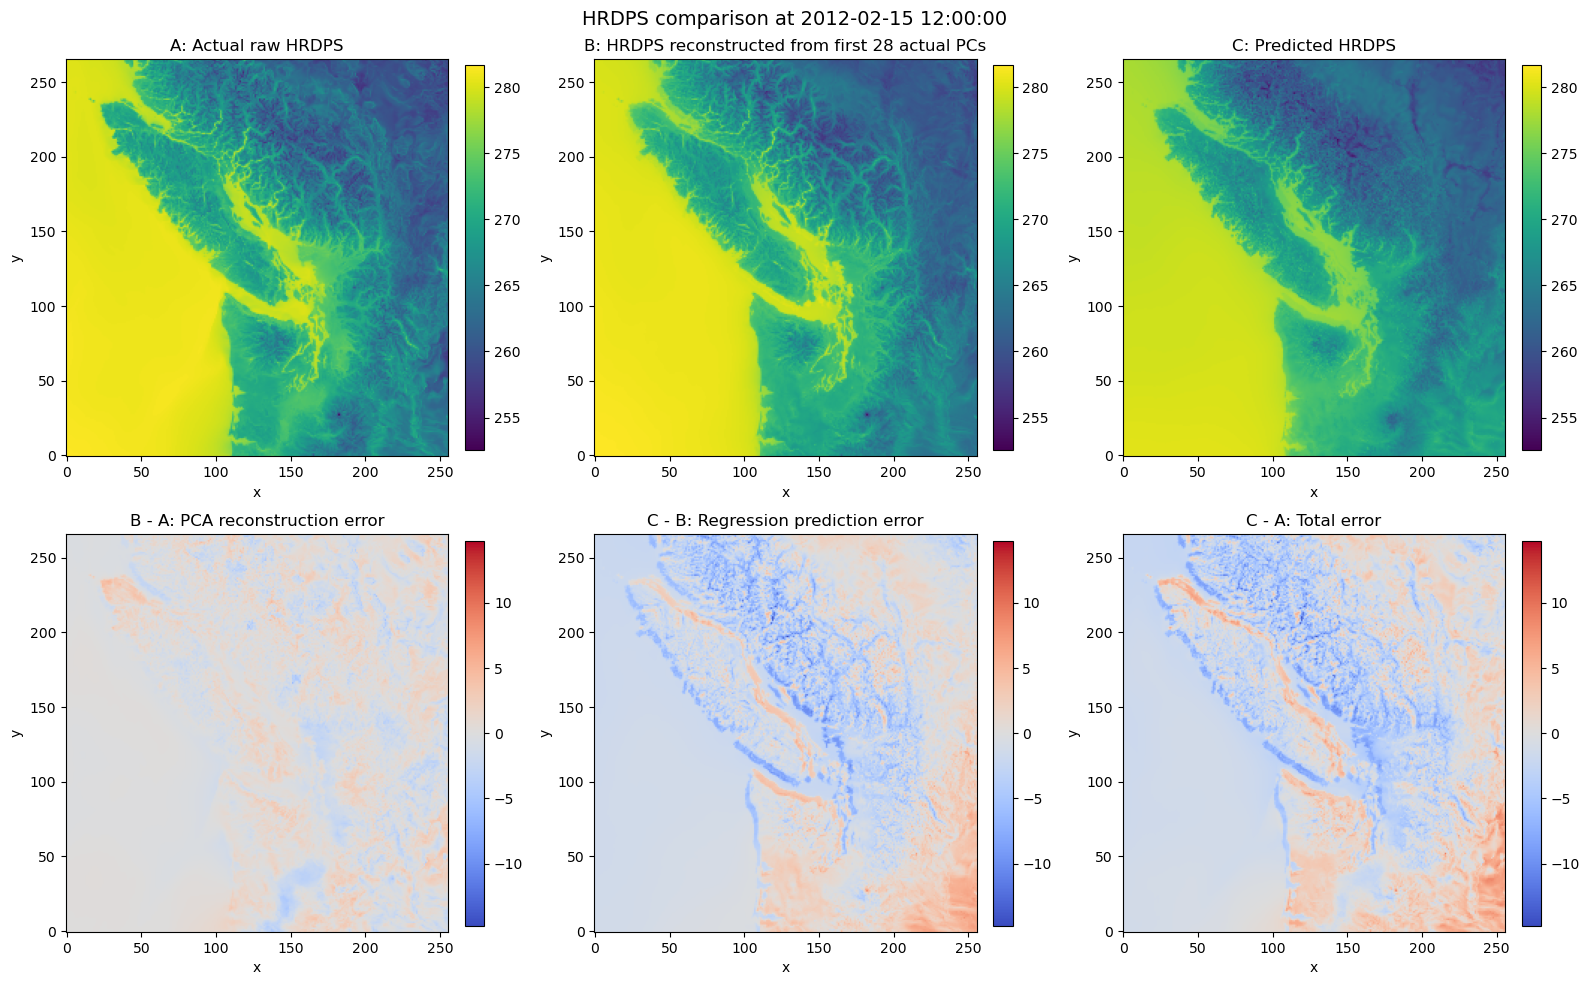

In [105]:
plot_hrdps_6_maps(
    timestamp="2012-02-15 12:00:00",
    ds_hrdps=ds_hrdps_test,
    X_hrdps=X_hrdps_test,
    X_hrdps_pred=X_hrdps_test_pred,
    pca_hrdps=pca_hrdps,
    n_hrdps_final=n_hrdps_final,
    valid_hrdps_cells=valid_hrdps_cells,
    filtered_times=test_times
)

In [106]:
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_final]

hrdps_test_scores_full = np.zeros(
    (hrdps_test_scores.shape[0], pca_hrdps.components_.shape[0]),
    dtype=np.float32
)

hrdps_test_scores_full[:, :n_hrdps_final] = hrdps_test_scores

X_hrdps_test_recon = pca_hrdps.inverse_transform(hrdps_test_scores_full)

In [107]:
def mean_field_full_grid(X_valid, full_shape, valid_hrdps_cells):
    mean_valid = X_valid.mean(axis=0)
    full_grid = np.full(full_shape[0] * full_shape[1], np.nan, dtype=np.float32)
    full_grid[valid_hrdps_cells] = mean_valid
    return full_grid.reshape(full_shape)

In [108]:
full_shape = ds_hrdps_test["tair"].shape[1:]   # (y, x)

A = mean_field_full_grid(X_hrdps_test, full_shape, valid_hrdps_cells)
B = mean_field_full_grid(X_hrdps_test_recon, full_shape, valid_hrdps_cells)
C = mean_field_full_grid(X_hrdps_test_pred, full_shape, valid_hrdps_cells)

In [109]:
BA = B - A
CB = C - B
CA = C - A

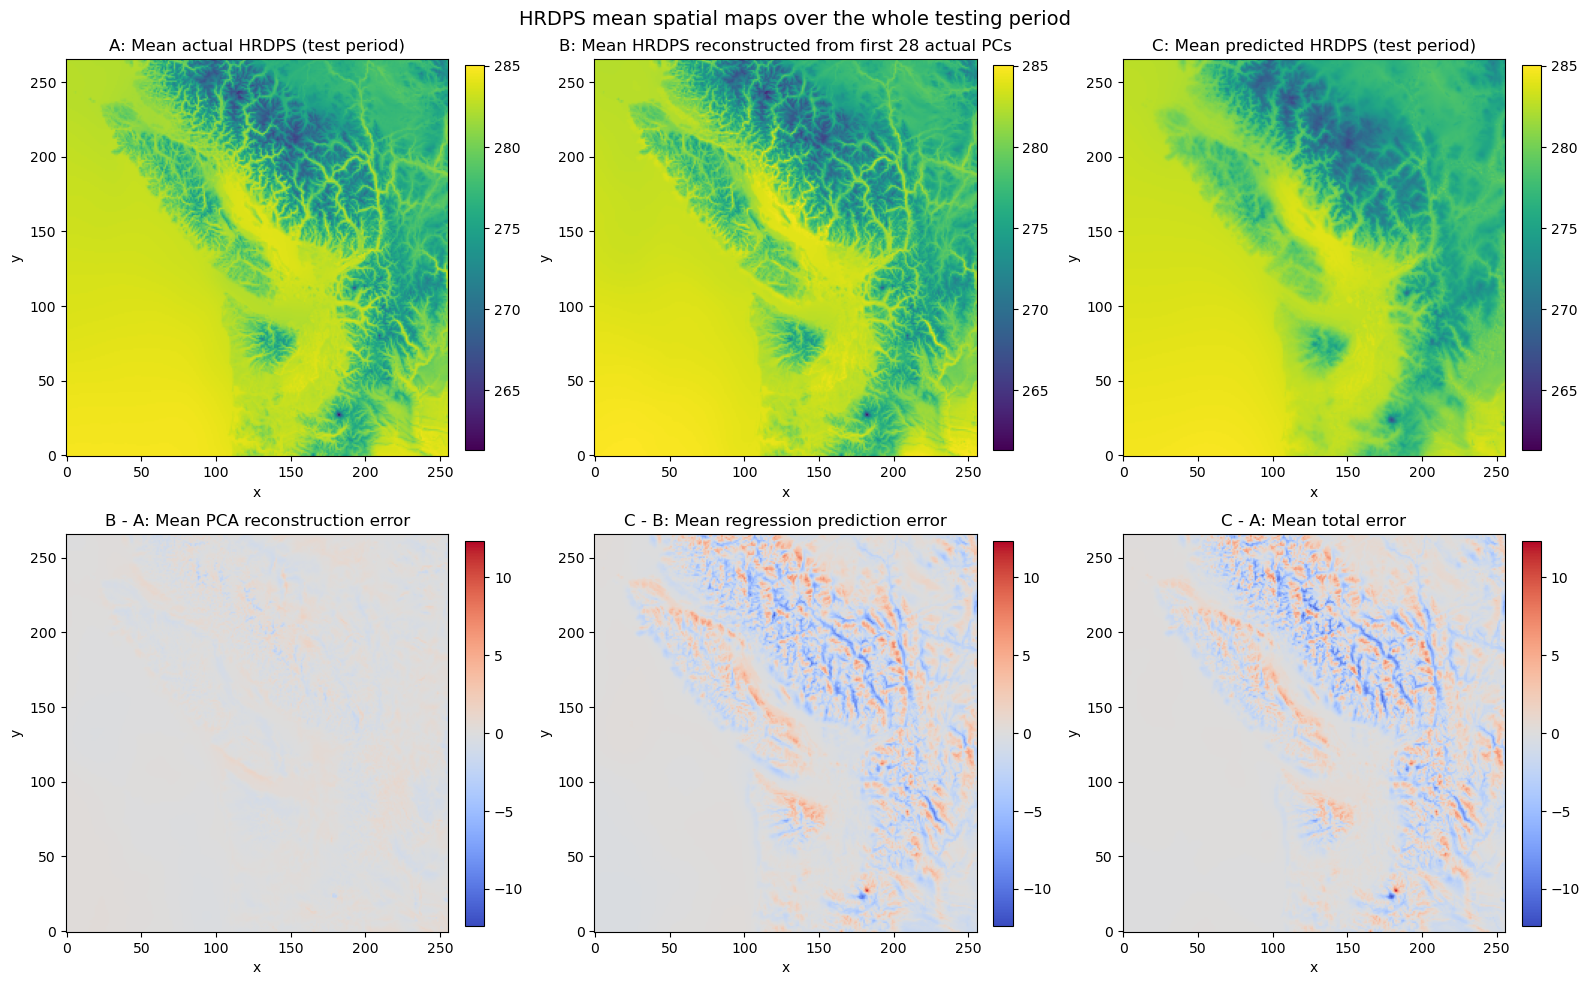

In [110]:
common_min = np.nanmin([A, B, C])
common_max = np.nanmax([A, B, C])

diff_abs_max = np.nanmax(np.abs([BA, CB, CA]))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

im0 = axes[0, 0].imshow(A, origin="lower", vmin=common_min, vmax=common_max)
axes[0, 0].set_title("A: Mean actual HRDPS (test period)")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(B, origin="lower", vmin=common_min, vmax=common_max)
axes[0, 1].set_title(f"B: Mean HRDPS reconstructed from first {n_hrdps_final} actual PCs")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(C, origin="lower", vmin=common_min, vmax=common_max)
axes[0, 2].set_title("C: Mean predicted HRDPS (test period)")
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

im3 = axes[1, 0].imshow(BA, origin="lower", cmap="coolwarm",vmin=-diff_abs_max, vmax=diff_abs_max)
axes[1, 0].set_title("B - A: Mean PCA reconstruction error")
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(CB, origin="lower", cmap="coolwarm",vmin=-diff_abs_max, vmax=diff_abs_max)
axes[1, 1].set_title("C - B: Mean regression prediction error")
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(CA, origin="lower", cmap="coolwarm",vmin=-diff_abs_max, vmax=diff_abs_max)
axes[1, 2].set_title("C - A: Mean total error")
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle("HRDPS mean spatial maps over the whole testing period", fontsize=14)
plt.tight_layout()
plt.show()

In [111]:
hrdps_test_scores_actual = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_final]

canrcm_test_scores = pca_canrcm.transform(X_canrcm_test)[:, :n_canrcm_final]
hrdps_test_scores_pred = regression_model.predict(canrcm_test_scores)

In [112]:
def make_pc_contribution_map(mean_score, pc_index, pca_hrdps, full_shape, valid_hrdps_cells):
    pc_pattern_valid = pca_hrdps.components_[pc_index]
    contribution_valid = mean_score * pc_pattern_valid
    full_map = np.full(full_shape[0] * full_shape[1], np.nan, dtype=np.float32)
    full_map[valid_hrdps_cells] = contribution_valid
    return full_map.reshape(full_shape)

In [113]:
def plot_pc_contributions_test_period(pca_hrdps, hrdps_test_scores_actual, hrdps_test_scores_pred,
                                      ds_hrdps_test, valid_hrdps_cells):
    full_shape = ds_hrdps_test["tair"].shape[1:]   # (y, x)

    fig, axes = plt.subplots(3, 3, figsize=(15, 14))

    for pc_index in range(3):
        actual_mean_score = hrdps_test_scores_actual[:, pc_index].mean()
        predicted_mean_score = hrdps_test_scores_pred[:, pc_index].mean()

        actual_map = make_pc_contribution_map(
            actual_mean_score,
            pc_index,
            pca_hrdps,
            full_shape,
            valid_hrdps_cells
        )

        predicted_map = make_pc_contribution_map(
            predicted_mean_score,
            pc_index,
            pca_hrdps,
            full_shape,
            valid_hrdps_cells
        )

        difference_map = predicted_map - actual_map

        absmax_main = np.nanmax(np.abs([actual_map, predicted_map]))
        absmax_diff = np.nanmax(np.abs(difference_map))

        im0 = axes[pc_index, 0].imshow(
            actual_map,
            origin="lower",
            cmap="coolwarm",
            vmin=-absmax_main,
            vmax=absmax_main
        )
        axes[pc_index, 0].set_title(f"PC{pc_index+1}: Actual contribution")
        plt.colorbar(im0, ax=axes[pc_index, 0], fraction=0.046, pad=0.04)

        im1 = axes[pc_index, 1].imshow(
            predicted_map,
            origin="lower",
            cmap="coolwarm",
            vmin=-absmax_main,
            vmax=absmax_main
        )
        axes[pc_index, 1].set_title(f"PC{pc_index+1}: Predicted contribution")
        plt.colorbar(im1, ax=axes[pc_index, 1], fraction=0.046, pad=0.04)

        im2 = axes[pc_index, 2].imshow(
            difference_map,
            origin="lower",
            cmap="coolwarm",
            vmin=-absmax_diff,
            vmax=absmax_diff
        )
        axes[pc_index, 2].set_title(f"PC{pc_index+1}: Predicted - Actual")
        plt.colorbar(im2, ax=axes[pc_index, 2], fraction=0.046, pad=0.04)

        for j in range(3):
            axes[pc_index, j].set_xlabel("x")
            axes[pc_index, j].set_ylabel("y")

    plt.suptitle("HRDPS PC1–PC3 contribution maps over the testing period")
    plt.tight_layout()
    plt.show()

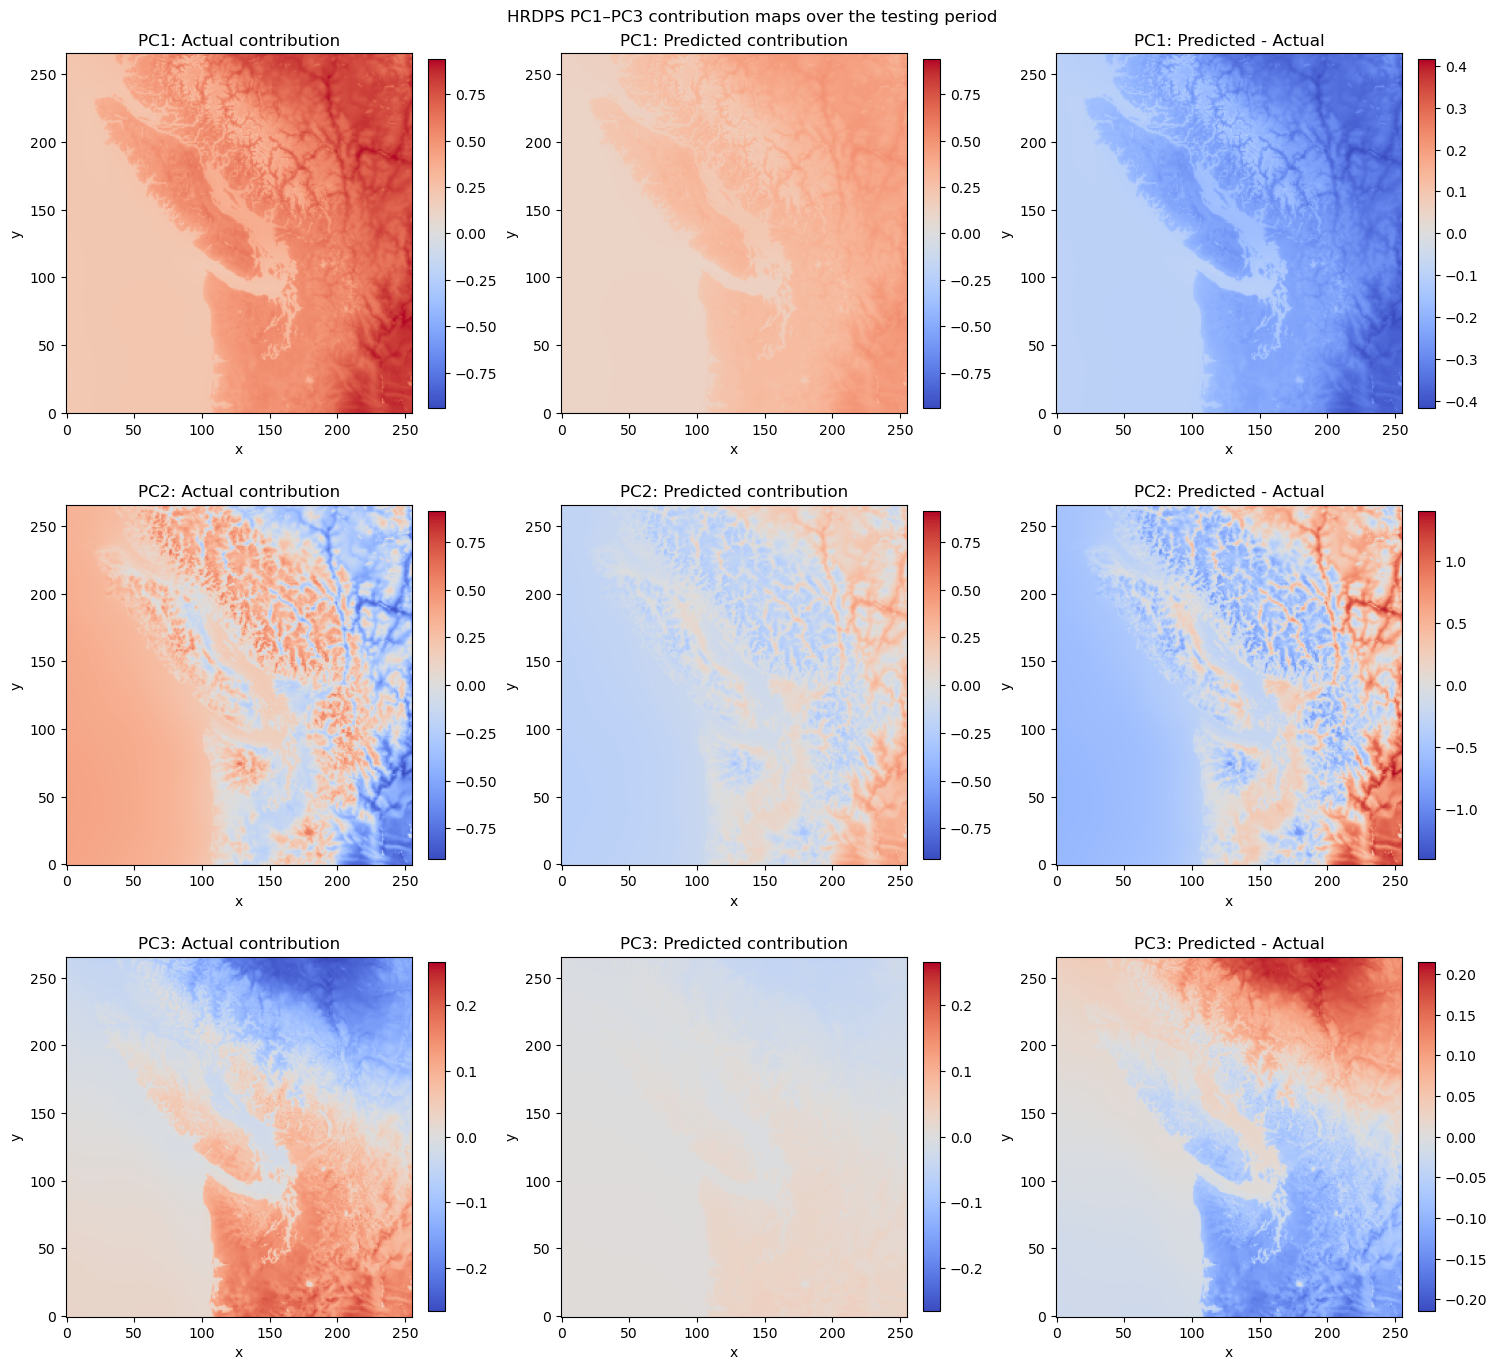

In [114]:
plot_pc_contributions_test_period(
    pca_hrdps,
    hrdps_test_scores_actual,
    hrdps_test_scores_pred,
    ds_hrdps_test,
    valid_hrdps_cells
)